In [11]:
!pip install ultralytics

In [12]:
!pip install ultralytics roboflow --quiet
import ultralytics
ultralytics.checks()
print('\n✅ Ready to train!')

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.9/112.6 GB disk)

✅ Ready to train!


In [13]:
!nvidia-smi

Wed Mar 11 09:08:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             32W /   70W |     405MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
!pip install roboflow

In [15]:
from roboflow import Roboflow

rf      = Roboflow(api_key="xFYKgwNc76XrQIbYEgJo")
project = rf.workspace("jonnadas-workspace-m5dgy").project("water-bottle-detection-b9fu2")
version = project.version(2)           # ← changed from 1 to 2
dataset = version.download("yolov8")

DATA_YAML = dataset.location + "/data.yaml"

import yaml
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

print(f'\n✅ Dataset ready!')
print(f'   Classes    : {cfg["names"]}')
print(f'   Num Classes: {cfg["nc"]}')
print(f'   data.yaml  : {DATA_YAML}')

loading Roboflow workspace...
loading Roboflow project...

✅ Dataset ready!
   Classes    : ['plastic_bottle', 'steel_bottle']
   Num Classes: 2
   data.yaml  : /content/Water-Bottle-Detection-2/data.yaml


In [18]:
import pandas as pd

csv_path = RUN_DIR + 'results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# ── Best values across all epochs ──
best_map50     = df['metrics/mAP50(B)'].max()
best_map5095   = df['metrics/mAP50-95(B)'].max()
best_precision = df['metrics/precision(B)'].max()
best_recall    = df['metrics/recall(B)'].max()
best_epoch     = int(df['metrics/mAP50(B)'].idxmax()) + 1
total_epochs   = len(df)

print('=' * 50)
print('   TRAINING RESULTS SUMMARY')
print('=' * 50)
print(f'  Run Name     : {RUN_NAME}')
print(f'  Total Epochs : {total_epochs}')
print(f'  Best Epoch   : {best_epoch}')
print()
print(f'  mAP@50       : {best_map50:.4f}   →  {best_map50*100:.1f}%')
print(f'  mAP@50-95    : {best_map5095:.4f}   →  {best_map5095*100:.1f}%')
print(f'  Precision    : {best_precision:.4f}   →  {best_precision*100:.1f}%')
print(f'  Recall       : {best_recall:.4f}   →  {best_recall*100:.1f}%')
print('=' * 50)

# ── Grade your model ──
print()
if best_map50 >= 0.90:
    grade = 'Excellent!'
elif best_map50 >= 0.75:
    grade = 'Good — ready to use'
elif best_map50 >= 0.60:
    grade = 'Decent — try more epochs or yolov8s.pt'
else:
    grade = 'Needs improvement — add more images or train longer'

print(f'  Model Grade  : {grade}')
print()

# ── What the metrics mean ──
print('What do these numbers mean?')
print('  mAP@50    → Main score. How well the model finds bottles.')
print('              90%+ = excellent, 75%+ = good, 60%+ = ok')
print('  mAP@50-95 → Stricter score — box must be very precisely placed.')
print('  Precision → Of all detections, how many were correct?')
print('              90% precision = 9 out of 10 detections are real bottles')
print('  Recall    → Of all real bottles, how many did it find?')
print('              80% recall = found 8 out of every 10 bottles')

# ── Show last 5 epochs ──
print(f'\n Last 5 Epochs:')
cols = ['epoch', 'metrics/precision(B)', 'metrics/recall(B)',
        'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'train/box_loss']
avail = [c for c in cols if c in df.columns]
print(df[avail].tail(5).rename(columns={
    'metrics/precision(B)' : 'Precision',
    'metrics/recall(B)'    : 'Recall',
    'metrics/mAP50(B)'     : 'mAP@50',
    'metrics/mAP50-95(B)'  : 'mAP@50-95',
    'train/box_loss'       : 'BoxLoss'
}).to_string(index=False))

   TRAINING RESULTS SUMMARY
  Run Name     : wbd_0311_0908_ep50
  Total Epochs : 50
  Best Epoch   : 49

  mAP@50       : 0.9807   →  98.1%
  mAP@50-95    : 0.8561   →  85.6%
  Precision    : 0.9789   →  97.9%
  Recall       : 0.9808   →  98.1%

  Model Grade  : Excellent!

What do these numbers mean?
  mAP@50    → Main score. How well the model finds bottles.
              90%+ = excellent, 75%+ = good, 60%+ = ok
  mAP@50-95 → Stricter score — box must be very precisely placed.
  Precision → Of all detections, how many were correct?
              90% precision = 9 out of 10 detections are real bottles
  Recall    → Of all real bottles, how many did it find?
              80% recall = found 8 out of every 10 bottles

 Last 5 Epochs:
 epoch  Precision  Recall  mAP@50  mAP@50-95  BoxLoss
    46    0.97463 0.94629 0.97827    0.84937  0.47547
    47    0.96810 0.98077 0.97971    0.85610  0.47896
    48    0.97894 0.95897 0.98060    0.84302  0.46984
    49    0.96136 0.98077 0.98070    0.84

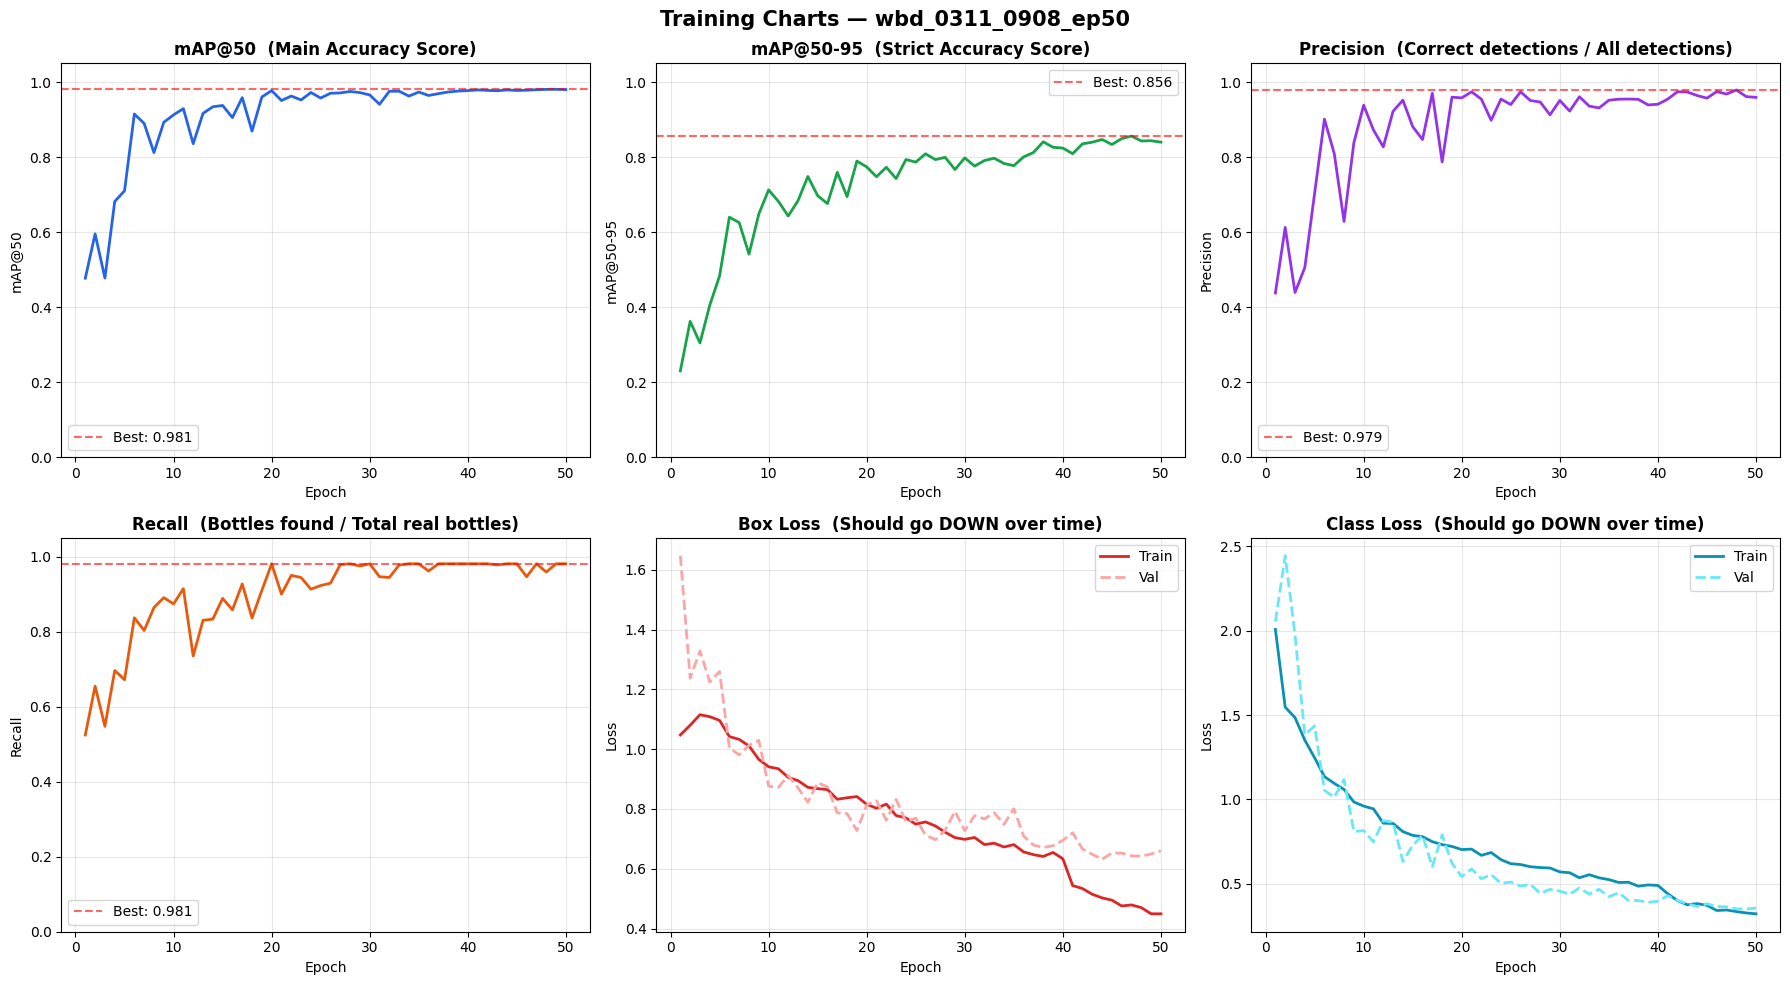

  Charts saved to: runs/detect/wbd_0311_0908_ep50/my_charts.png

  How to read these charts:
  mAP / Precision / Recall → should go UP and flatten at top
  Box Loss / Class Loss    → should go DOWN and flatten near 0
  If train loss goes down but val loss goes UP → overfitting (need more images)


In [19]:
import matplotlib.pyplot as plt

epochs = df['epoch']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Training Charts — {RUN_NAME}', fontsize=15, fontweight='bold')

# 1. mAP@50
ax = axes[0,0]
ax.plot(epochs, df['metrics/mAP50(B)'], color='#2563EB', linewidth=2)
ax.axhline(best_map50, color='red', linestyle='--', alpha=0.6, label=f'Best: {best_map50:.3f}')
ax.set_title('mAP@50  (Main Accuracy Score)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('mAP@50')
ax.grid(True, alpha=0.3); ax.legend()
ax.set_ylim(0, 1.05)

# 2. mAP@50-95
ax = axes[0,1]
ax.plot(epochs, df['metrics/mAP50-95(B)'], color='#16A34A', linewidth=2)
ax.axhline(best_map5095, color='red', linestyle='--', alpha=0.6, label=f'Best: {best_map5095:.3f}')
ax.set_title('mAP@50-95  (Strict Accuracy Score)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('mAP@50-95')
ax.grid(True, alpha=0.3); ax.legend()
ax.set_ylim(0, 1.05)

# 3. Precision
ax = axes[0,2]
ax.plot(epochs, df['metrics/precision(B)'], color='#9333EA', linewidth=2)
ax.axhline(best_precision, color='red', linestyle='--', alpha=0.6, label=f'Best: {best_precision:.3f}')
ax.set_title('Precision  (Correct detections / All detections)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Precision')
ax.grid(True, alpha=0.3); ax.legend()
ax.set_ylim(0, 1.05)

# 4. Recall
ax = axes[1,0]
ax.plot(epochs, df['metrics/recall(B)'], color='#EA580C', linewidth=2)
ax.axhline(best_recall, color='red', linestyle='--', alpha=0.6, label=f'Best: {best_recall:.3f}')
ax.set_title('Recall  (Bottles found / Total real bottles)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Recall')
ax.grid(True, alpha=0.3); ax.legend()
ax.set_ylim(0, 1.05)

# 5. Box Loss
ax = axes[1,1]
ax.plot(epochs, df['train/box_loss'], color='#DC2626', linewidth=2, label='Train')
if 'val/box_loss' in df.columns:
    ax.plot(epochs, df['val/box_loss'], color='#FCA5A5', linewidth=2, linestyle='--', label='Val')
ax.set_title('Box Loss  (Should go DOWN over time)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3); ax.legend()

# 6. Class Loss
ax = axes[1,2]
ax.plot(epochs, df['train/cls_loss'], color='#0891B2', linewidth=2, label='Train')
if 'val/cls_loss' in df.columns:
    ax.plot(epochs, df['val/cls_loss'], color='#67E8F9', linewidth=2, linestyle='--', label='Val')
ax.set_title('Class Loss  (Should go DOWN over time)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout()
plt.savefig(RUN_DIR + 'my_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print('  Charts saved to:', RUN_DIR + 'my_charts.png')
print()
print('  How to read these charts:')
print('  mAP / Precision / Recall → should go UP and flatten at top')
print('  Box Loss / Class Loss    → should go DOWN and flatten near 0')
print('  If train loss goes down but val loss goes UP → overfitting (need more images)')

🔍 Found 2 training run(s)

               Run  Epochs  mAP@50 %  mAP@50-95 %  Precision %  Recall %  Final Loss
wbd_0311_0845_ep50      50      98.1         85.6         97.9      98.1      0.4492
wbd_0311_0908_ep50      50      98.1         85.6         97.9      98.1      0.4492

🏆 Best Run  : wbd_0311_0845_ep50
   mAP@50   : 98.1%
   Precision: 97.9%
   Recall   : 98.1%


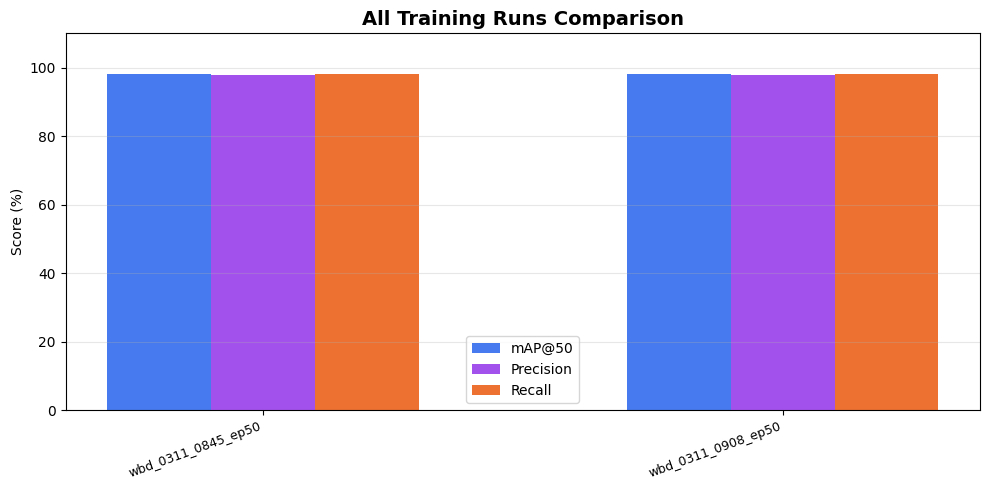


💾 Saved to: all_runs_summary.csv


In [20]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Find all runs (your old runs were train, train2, train3 + new named ones)
all_csvs = sorted(
    glob.glob('runs/detect/*/results.csv'),
    key=lambda x: os.path.getmtime(x)
)

if not all_csvs:
    print('⚠️  No training runs found yet.')
else:
    rows = []
    for csv in all_csvs:
        run_id = csv.split('/')[-2]
        try:
            d = pd.read_csv(csv)
            d.columns = d.columns.str.strip()
            rows.append({
                'Run'        : run_id,
                'Epochs'     : len(d),
                'mAP@50 %'   : round(d['metrics/mAP50(B)'].max() * 100, 1),
                'mAP@50-95 %': round(d['metrics/mAP50-95(B)'].max() * 100, 1),
                'Precision %': round(d['metrics/precision(B)'].max() * 100, 1),
                'Recall %'   : round(d['metrics/recall(B)'].max() * 100, 1),
                'Final Loss' : round(d['train/box_loss'].iloc[-1], 4),
            })
        except Exception as e:
            print(f'  Skipped {run_id}: {e}')

    summary = pd.DataFrame(rows)
    best_i  = summary['mAP@50 %'].idxmax()

    print(f'🔍 Found {len(summary)} training run(s)\n')
    print(summary.to_string(index=False))
    print()
    print(f'🏆 Best Run  : {summary.loc[best_i, "Run"]}')
    print(f'   mAP@50   : {summary.loc[best_i, "mAP@50 %"]}%')
    print(f'   Precision: {summary.loc[best_i, "Precision %"]}%')
    print(f'   Recall   : {summary.loc[best_i, "Recall %"]}%')

    # Bar chart (only if multiple runs)
    if len(summary) > 1:
        fig, ax = plt.subplots(figsize=(max(10, len(summary)*2), 5))
        x = range(len(summary))
        w = 0.2
        ax.bar([i + 0*w for i in x], summary['mAP@50 %'],    w, label='mAP@50',    color='#2563EB', alpha=0.85)
        ax.bar([i + 1*w for i in x], summary['Precision %'], w, label='Precision', color='#9333EA', alpha=0.85)
        ax.bar([i + 2*w for i in x], summary['Recall %'],    w, label='Recall',    color='#EA580C', alpha=0.85)
        ax.set_xticks([i + w for i in x])
        ax.set_xticklabels(summary['Run'], rotation=20, ha='right', fontsize=9)
        ax.set_ylabel('Score (%)')
        ax.set_title('All Training Runs Comparison', fontsize=14, fontweight='bold')
        ax.set_ylim(0, 110)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print()
        print('💡 Tip: Train again with different settings to compare runs here!')
        print('   Try: EPOCHS=100  or  MODEL="yolov8s.pt"')

    summary.to_csv('all_runs_summary.csv', index=False)
    print('\n💾 Saved to: all_runs_summary.csv')

In [2]:
!pip install ultralytics roboflow --quiet

import ultralytics
ultralytics.checks()
print('\n✅ Ready!')

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.8/112.6 GB disk)

✅ Ready!


In [3]:
from roboflow import Roboflow
from ultralytics import YOLO
import datetime, yaml

# ── Download v2 dataset (plastic + steel) ──
rf      = Roboflow(api_key="xFYKgwNc76XrQIbYEgJo")
project = rf.workspace("jonnadas-workspace-m5dgy").project("water-bottle-detection-b9fu2")
version = project.version(2)   # v2 has both classes
dataset = version.download("yolov8")

DATA_YAML = dataset.location + "/data.yaml"

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)
print(f'✅ Classes: {cfg["names"]}')   # Should show both classes

# ── Train ──
RUN_NAME = f"wbd_{datetime.datetime.now().strftime('%m%d_%H%M')}_ep50"
model    = YOLO('yolov8n.pt')
model.train(
    data    = DATA_YAML,
    epochs  = 50,
    imgsz   = 640,
    batch   = 8,
    name    = RUN_NAME,
    plots   = True,
    save    = True,
)

BEST_PT = f'runs/detect/{RUN_NAME}/weights/best.pt'
print(f'\n✅ Training done! Model: {BEST_PT}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Water-Bottle-Detection-2 in yolov8:: 100%|██████████| 1964/1964 [00:00<00:00, 7947.26it/s]


✅ Classes: ['plastic_bottle', 'steel_bottle']
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Water-Bottle-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wbd_0311_0845_ep50, nbs=64, nms=False, opset=None, opti

In [7]:
# Mount Google Drive and save model permanently
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs('/content/drive/MyDrive/WaterBottleModel', exist_ok=True)
shutil.copy(
    '/content/runs/detect/wbd_0311_0845_ep50/weights/best.pt',
    '/content/drive/MyDrive/WaterBottleModel/best.pt')

print('✅ Model saved to Google Drive permanently!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to Google Drive permanently!


In [8]:
from google.colab import drive
drive.mount('/content/drive')

BEST_PT = '/content/drive/MyDrive/WaterBottleModel/best.pt'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


🔄 Loading model: /content/drive/MyDrive/WaterBottleModel/best.pt
✅ Model loaded!
🏷️  Classes: {0: 'plastic_bottle', 1: 'steel_bottle'}
🎯 Confidence threshold: 0.4

🎥 Starting webcam...
   → Allow camera access in your browser when asked!
✅ Camera ready! Detection starting...

🟠 Orange box = plastic_bottle
🔵 Blue box   = steel_bottle


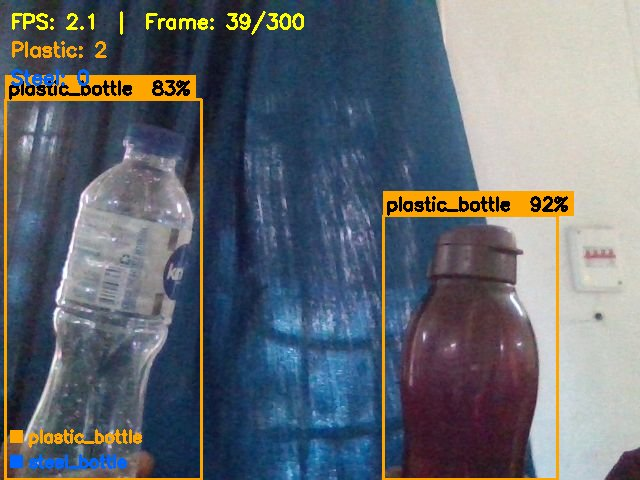


⛔ Stopped by user.

✅ Detection complete!
   Frames : 39
   Time   : 18.7s
   Avg FPS: 2.1


In [39]:
import cv2
import numpy as np
import time
from IPython.display import display, Image as IPImage
from google.colab.output import eval_js
from base64 import b64decode, b64encode
from ultralytics import YOLO

# ── Settings ──────────────────────────────────────────
BEST_PT = '/content/drive/MyDrive/WaterBottleModel/best.pt'
CONFIDENCE = 0.4    # Detection threshold (0.0 - 1.0)
MAX_FRAMES = 300    # How many frames to run (increase for longer session)
# ──────────────────────────────────────────────────────

# Colors per class (BGR for OpenCV)
CLASS_COLORS = {
    'plastic_bottle': (0, 165, 255),   # Orange
    'steel_bottle'  : (255, 100,  0),  # Blue
}
DEFAULT_COLOR = (0, 255, 0)

# ── Load model ──
print(f'🔄 Loading model: {BEST_PT}')
model = YOLO(BEST_PT)
print(f'✅ Model loaded!')
print(f'🏷️  Classes: {model.names}')
print(f'🎯 Confidence threshold: {CONFIDENCE}')

# ── Helper functions ──
def draw_boxes(frame, results, model):
    count = {'plastic_bottle': 0, 'steel_bottle': 0}
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls_id   = int(box.cls[0])
            conf     = float(box.conf[0])
            cls_name = model.names[cls_id]
            color    = CLASS_COLORS.get(cls_name, DEFAULT_COLOR)

            # Box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # Label background + text
            label = f'{cls_name}  {conf:.0%}'
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(frame, (x1, y1 - th - 10), (x1 + tw + 6, y1), color, -1)
            cv2.putText(frame, label, (x1 + 3, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

            if cls_name in count:
                count[cls_name] += 1
    return frame, count

def add_overlay(frame, count, fps, frame_num):
    # FPS + frame counter
    cv2.putText(frame, f'FPS: {fps:.1f}  |  Frame: {frame_num}/{MAX_FRAMES}',
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 255), 2)

    # Detection counts
    cv2.putText(frame, f'Plastic: {count["plastic_bottle"]}',
                (10, 56), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 165, 255), 2)
    cv2.putText(frame, f'Steel: {count["steel_bottle"]}',
                (10, 84), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 100, 0), 2)

    # Legend bottom-left
    h = frame.shape[0]
    cv2.rectangle(frame, (10, h-50), (22, h-38), (0,165,255), -1)
    cv2.putText(frame, 'plastic_bottle', (28, h-38),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,165,255), 2)
    cv2.rectangle(frame, (10, h-25), (22, h-13), (255,100,0), -1)
    cv2.putText(frame, 'steel_bottle', (28, h-13),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,100,0), 2)
    return frame

# ── JavaScript to access browser webcam ──
JS_SETUP = """
async function setupWebcam() {
    const video = document.createElement('video');
    video.width = 640; video.height = 480;
    video.style.display = 'none';
    document.body.appendChild(video);
    const stream = await navigator.mediaDevices.getUserMedia({ video: true });
    video.srcObject = stream;
    await video.play();
    window._vid = video;
    return 'Webcam ready!';
}
setupWebcam();
"""

JS_CAPTURE = """
async function captureFrame() {
    const v = window._vid;
    const c = document.createElement('canvas');
    c.width = v.videoWidth || 640;
    c.height = v.videoHeight || 480;
    c.getContext('2d').drawImage(v, 0, 0);
    return c.toDataURL('image/jpeg', 0.8);
}
captureFrame();
"""

JS_STOP = """
if (window._vid && window._vid.srcObject)
    window._vid.srcObject.getTracks().forEach(t => t.stop());
'Camera stopped';
"""

# ── Start webcam ──
print('\n🎥 Starting webcam...')
print('   → Allow camera access in your browser when asked!')
eval_js(JS_SETUP)
print('✅ Camera ready! Detection starting...\n')
print('🟠 Orange box = plastic_bottle')
print('🔵 Blue box   = steel_bottle')

# ── Detection loop ──
frame_count    = 0
start_time     = time.time()
display_handle = display(IPImage(data=b''), display_id=True)

try:
    while frame_count < MAX_FRAMES:
        # Capture frame from browser
        b64 = eval_js(JS_CAPTURE)
        if ',' in b64:
            b64 = b64.split(',')[1]
        frame = cv2.imdecode(
            np.frombuffer(b64decode(b64), dtype=np.uint8),
            cv2.IMREAD_COLOR
        )
        if frame is None:
            continue

        # Run YOLOv8 detection
        results = model.predict(
            source  = frame,
            conf    = CONFIDENCE,
            verbose = False
        )

        # Draw boxes
        frame, count = draw_boxes(frame.copy(), results, model)

        # FPS
        elapsed     = time.time() - start_time
        fps         = frame_count / elapsed if elapsed > 0 else 0
        frame_count += 1

        # Overlay info
        frame = add_overlay(frame, count, fps, frame_count)

        # Show in Colab
        _, buf = cv2.imencode('.jpg', frame, [cv2.IMWRITE_JPEG_QUALITY, 85])
        display_handle.update(IPImage(data=buf.tobytes()))

except KeyboardInterrupt:
    print('\n⛔ Stopped by user.')
finally:
    eval_js(JS_STOP)
    elapsed = time.time() - start_time
    print(f'\n✅ Detection complete!')
    print(f'   Frames : {frame_count}')
    print(f'   Time   : {elapsed:.1f}s')
    print(f'   Avg FPS: {frame_count/elapsed:.1f}')